In [74]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.image as mpimg
from skimage import exposure
from data.preprocess.preprocessing import open_image

plt.rcParams.update({'font.size': 16})

In [109]:
def combine_images_with_labels_slices(images, labels, rows, cols, msk):
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
    axes = axes.flatten()

    for i, (image, label) in enumerate(zip(images, labels)):
        adjusted_image = np.copy(image)
        x, y = np.where(msk == 0)
        for channel in range(3):  
            adjusted_image[x, y, channel] = exposure.rescale_intensity(adjusted_image[x, y, channel], in_range=(0.0, 0.4))
   
        axes[i].imshow(adjusted_image, cmap='gray')
        axes[i].set_title(label)
        axes[i].axis('off')

    plt.subplots_adjust(wspace=0, hspace=20)
    plt.tight_layout()
    return fig

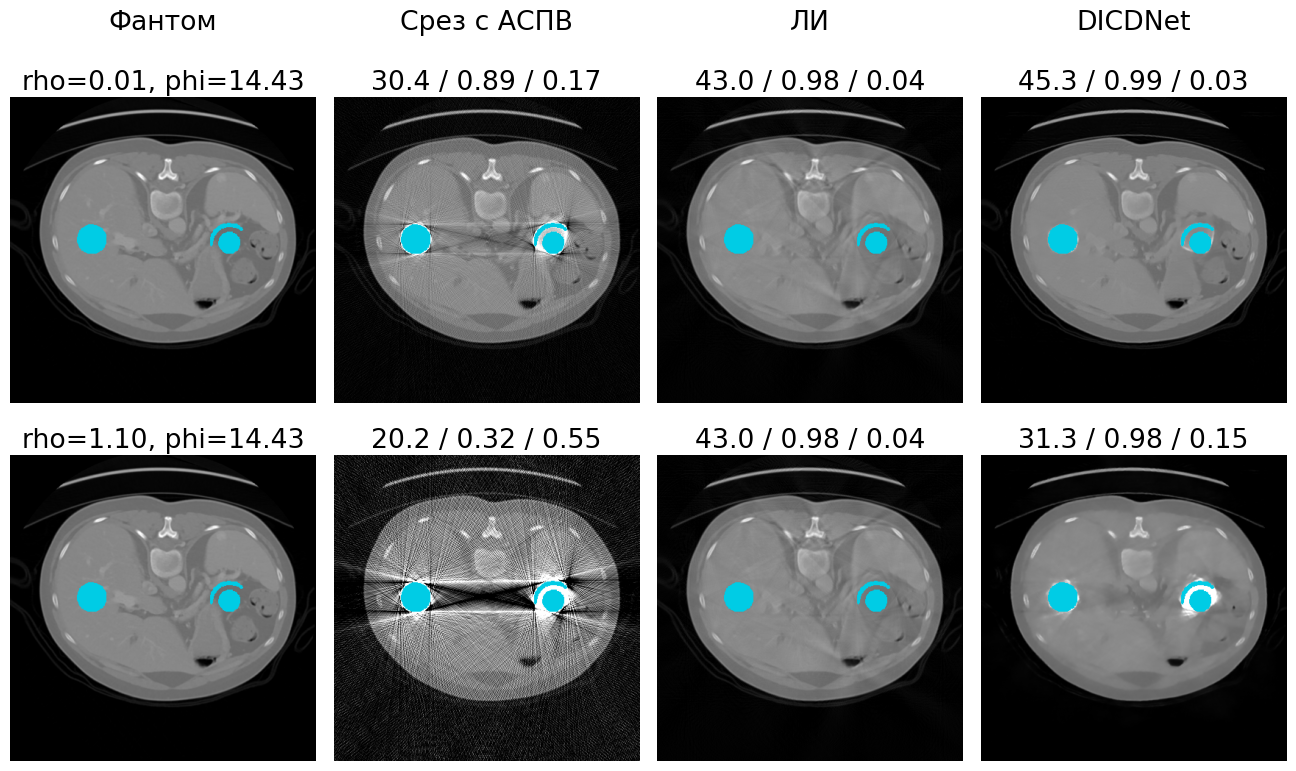

In [110]:
mask = open_image('E:/DICDNet/data/mask/mask7.tif', 'float32', 416, 416)
names = ['E:/DICDNet/data/test/img_170.tif',
         'E:/DICDNet/data/generated/Xma/rho=0.01/phi=14.43/img43/Xma_rho0.01_phi14.43_img43_mask7.tif',
         'E:/DICDNet/results/XLI/rho=0.01/phi=14.43/img43/XLI_rho0.01_phi14.43_img43_mask7.tif',
         'E:/DICDNet/results/Xpred/rho=0.01/phi=14.43/img43/Xpred_rho0.01_phi14.43_img43_mask7.tif',
         'E:/DICDNet/data/test/img_170.tif',
         'E:/DICDNet/data/generated/Xma/rho=1.10/phi=14.43/img43/Xma_rho1.10_phi14.43_img43_mask7.tif',
         'E:/DICDNet/results/XLI/rho=1.10/phi=14.43/img43/XLI_rho1.10_phi14.43_img43_mask7.tif',
         'E:/DICDNet/results/Xpred/rho=1.10/phi=14.43/img43/Xpred_rho1.10_phi14.43_img43_mask7.tif']
images = [open_image(name, 'float32', 416, 416).clip(min=0) for name in names]
colored = []

for image in images:
    x, y = np.where(mask != 0)
    colored_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.float32)
    colored_image[..., 0] = np.copy(image)
    colored_image[..., 1] = np.copy(image)
    colored_image[..., 2] = np.copy(image)
    colored_image[x, y, 0] = 0.0
    colored_image[x, y, 1] = 0.8
    colored_image[x, y, 2] = 0.9
    colored_image = np.clip(colored_image, 0.0, 1.0)
    colored.append(colored_image)

labels = ['Фантом\n\nrho=0.01, phi=14.43', 
          'Срез с АСПВ\n\n30.4 / 0.89 / 0.17',
          'ЛИ\n\n43.0 / 0.98 / 0.04',
          'DICDNet\n\n45.3 / 0.99 / 0.03',
          'rho=1.10, phi=14.43',
          '20.2 / 0.32 / 0.55',
          '43.0 / 0.98 / 0.04',
          '31.3 / 0.98 / 0.15']

fig = combine_images_with_labels_slices(colored, labels, rows=2, cols=4, msk=mask)
plt.savefig('E:/DICDNet/results.png', bbox_inches='tight', pad_inches=0)

In [115]:
def combine_images_with_labels(images, labels, rows, cols):
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
    axes = axes.flatten()

    for i, (image, label) in enumerate(zip(images, labels)):
        axes[i].imshow(image)
        axes[i].set_title(label)
        axes[i].axis('off')

    plt.subplots_adjust(wspace=0, hspace=20)
    plt.tight_layout()
    return fig

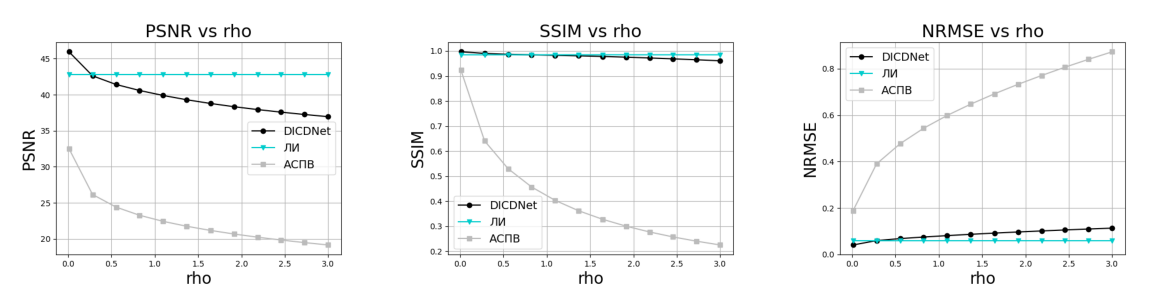

In [117]:
names = ['E:/DICDNet/results/all_rho/mask0/mask0_PSNR_phi28.657_rho.png',
         'E:/DICDNet/results/all_rho/mask0/mask0_SSIM_phi28.657_rho.png',
         'E:/DICDNet/results/all_rho/mask0/mask0_NRMSE_phi28.657_rho.png']
images = [mpimg.imread(name) for name in names]
labels = ['', '', '']

fig = combine_images_with_labels(images, labels, rows=1, cols=3)
plt.savefig('E:/DICDNet/plots_rho.png', bbox_inches='tight', pad_inches=0)

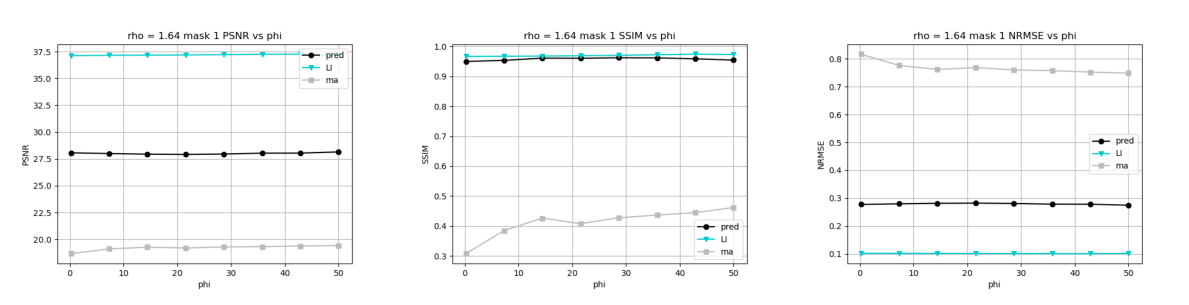

In [17]:
names = ['E:/DICDNet/results/all_phi/mask1/mask1_PSNR_rho1.641_phi.png',
         'E:/DICDNet/results/all_phi/mask1/mask1_SSIM_rho1.641_phi.png',
         'E:/DICDNet/results/all_phi/mask1/mask1_NRMSE_rho1.641_phi.png']
images = [mpimg.imread(name) for name in names]
labels = ['', '', '']

fig = combine_images_with_labels(images, labels, rows=1, cols=3)
plt.savefig('E:/DICDNet/plots_phi.png')

In [35]:
def combine_images_with_labels_slices_2d(images, labels, rows, cols, msk):
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
    axes = axes.flatten()

    for i, (image, label) in enumerate(zip(images, labels)):
        adjusted_image = np.copy(image)
        x, y = np.where(msk == 0)
        adjusted_image[x, y] = exposure.rescale_intensity(adjusted_image[x, y], in_range=(0.0, 0.5))
   
        axes[i].imshow(adjusted_image, cmap='gray')
        axes[i].set_title(label)
        axes[i].axis('off')

    plt.tight_layout()
    return fig

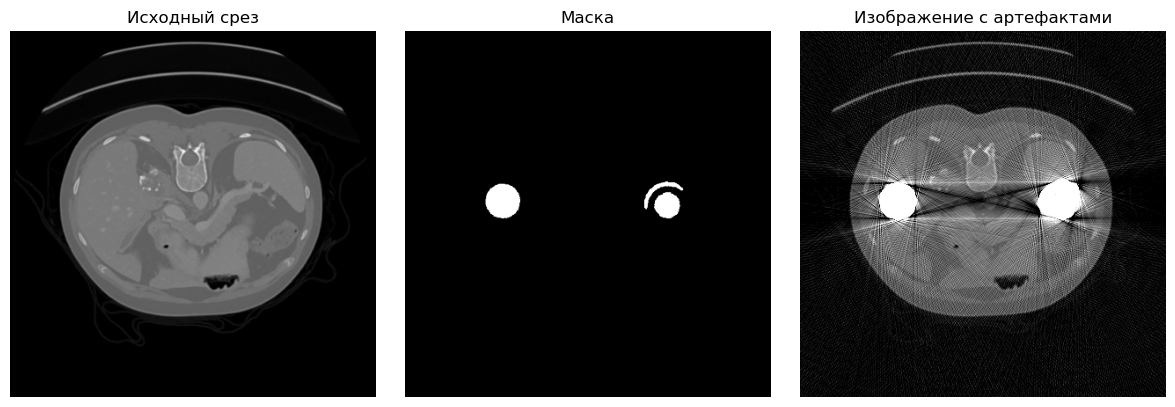

In [36]:
names = ['E:/DICDNet/data/test/img_87.tif',
         'E:/DICDNet/data/mask/mask7.tif',
         'E:/DICDNet/data/generated/Xma/rho=0.28/phi=7.31/img92/Xma_rho0.28_phi7.31_img92_mask7.tif']
images = [open_image(name, 'float32', 416, 416) for name in names]
labels = ['Исходный срез', 'Маска', 'Изображение с артефактами']

fig = combine_images_with_labels_slices_2d(images, labels, rows=1, cols=3, msk=np.zeros((416, 416)))
plt.savefig('E:/DICDNet/example.png')